# Project Setup

## Project Details (Add Project Name)

- **Dataset:** Home Credit Default Risk Dataset - "application_train.csv"  
- **Author:** Evan Reynolds
- **Date:** 17/07/2025
- **Objective:**   See MD File for scope
- **Status:** In Progress - Working on Section ***

## Environment and Imports

In [1]:
# ════════════════════════════════
# Environment Setup
# ════════════════════════════════

# ── Standard Library ────────────────────
import os
import sys
import warnings

# ── Data ──────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning (only needed once you start modelling) ──
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Jupyter ───────────────────────
from IPython.core.interactiveshell import InteractiveShell
from IPython.display import display


def find_repo_root(start, repo_name='CreditRiskLearning'):
    path = os.path.abspath(start)
    while True:
        if os.path.basename(path) == repo_name:
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError(f"Could not find repo root: {repo_name}")
        path = parent


repo_root = find_repo_root(os.getcwd())
sys.path.append(os.path.join(repo_root, 'Core Resources'))
sys.path.append(os.path.join(repo_root, 'Core Resources', 'Scripts'))

from python_style_util import f, s, p, palette, fonts, sizes, set_style, show_fonts, show_tokens, show_palette, show_style_guide, show_colormaps, C, Shade, Size
import evaluation_utils as eu
import missingno as msno        # missingness assessment functions

# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Display Settings

In [2]:
# --- Pandas ---
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places on floats
pd.set_option('display.max_columns', None)              # show all columns
pd.set_option('display.max_rows', 100)                  # show up to 100 rows
pd.set_option('display.width', None)                    # don't wrap wide dataframes
pd.set_option('display.colheader_justify', 'left')      # left-align column headers
pd.set_option('display.precision', 4)                   # decimal precision for describe()
pd.set_option('display.large_repr', 'truncate')         # truncate instead of summary for large dfs

# --- NumPy ---
np.set_printoptions(
    precision=4,        # decimal places
    suppress=True,      # no scientific notation
    linewidth=120,      # wrap width
    threshold=1000,     # show up to 1000 elements before summarising with ...
    edgeitems=5,        # show 5 items at each end when it does summarise
)

# --- Matplotlib ---
%matplotlib inline
plt.rcParams['figure.dpi'] = 120             # sharper figures
plt.rcParams['savefig.dpi'] = 150            # higher res when saving
plt.rcParams['savefig.bbox'] = 'tight'       # no clipped labels when saving
plt.rcParams['savefig.facecolor'] = 'white'  # white background on saved figures

# --- Jupyter ---
InteractiveShell.ast_node_interactivity = 'all'  # print every expression, not just the last

# --- Warnings ---
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# --- Style ---
set_style()

## Style Guide

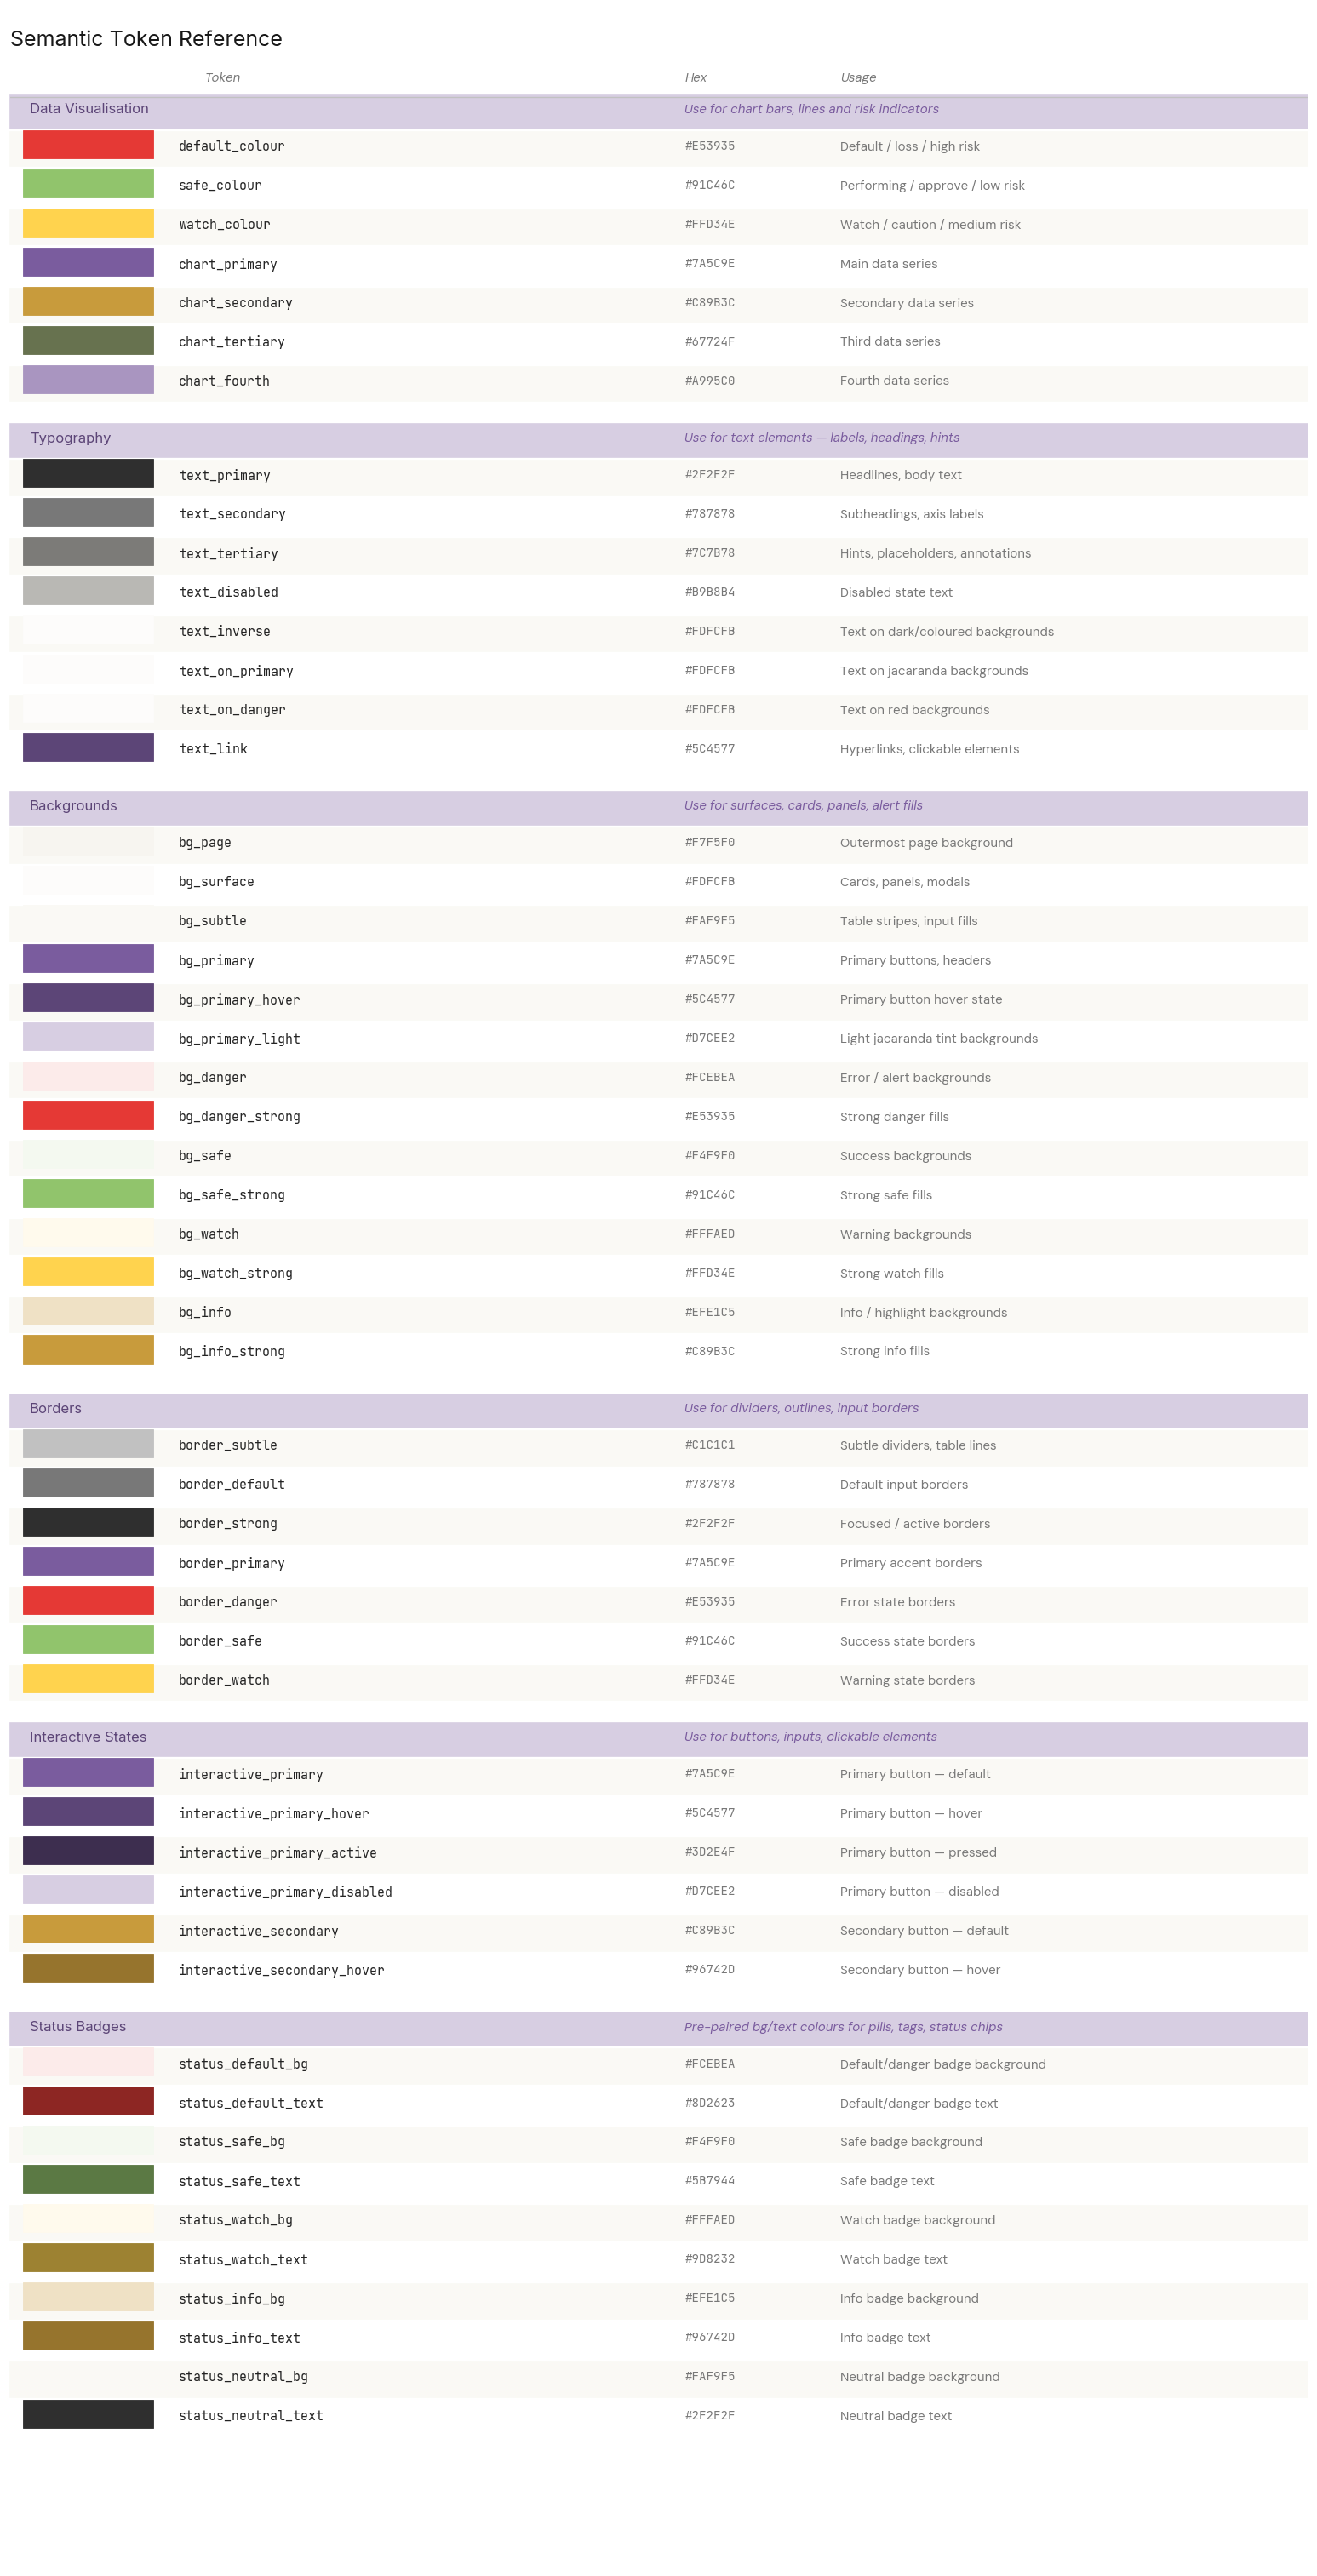

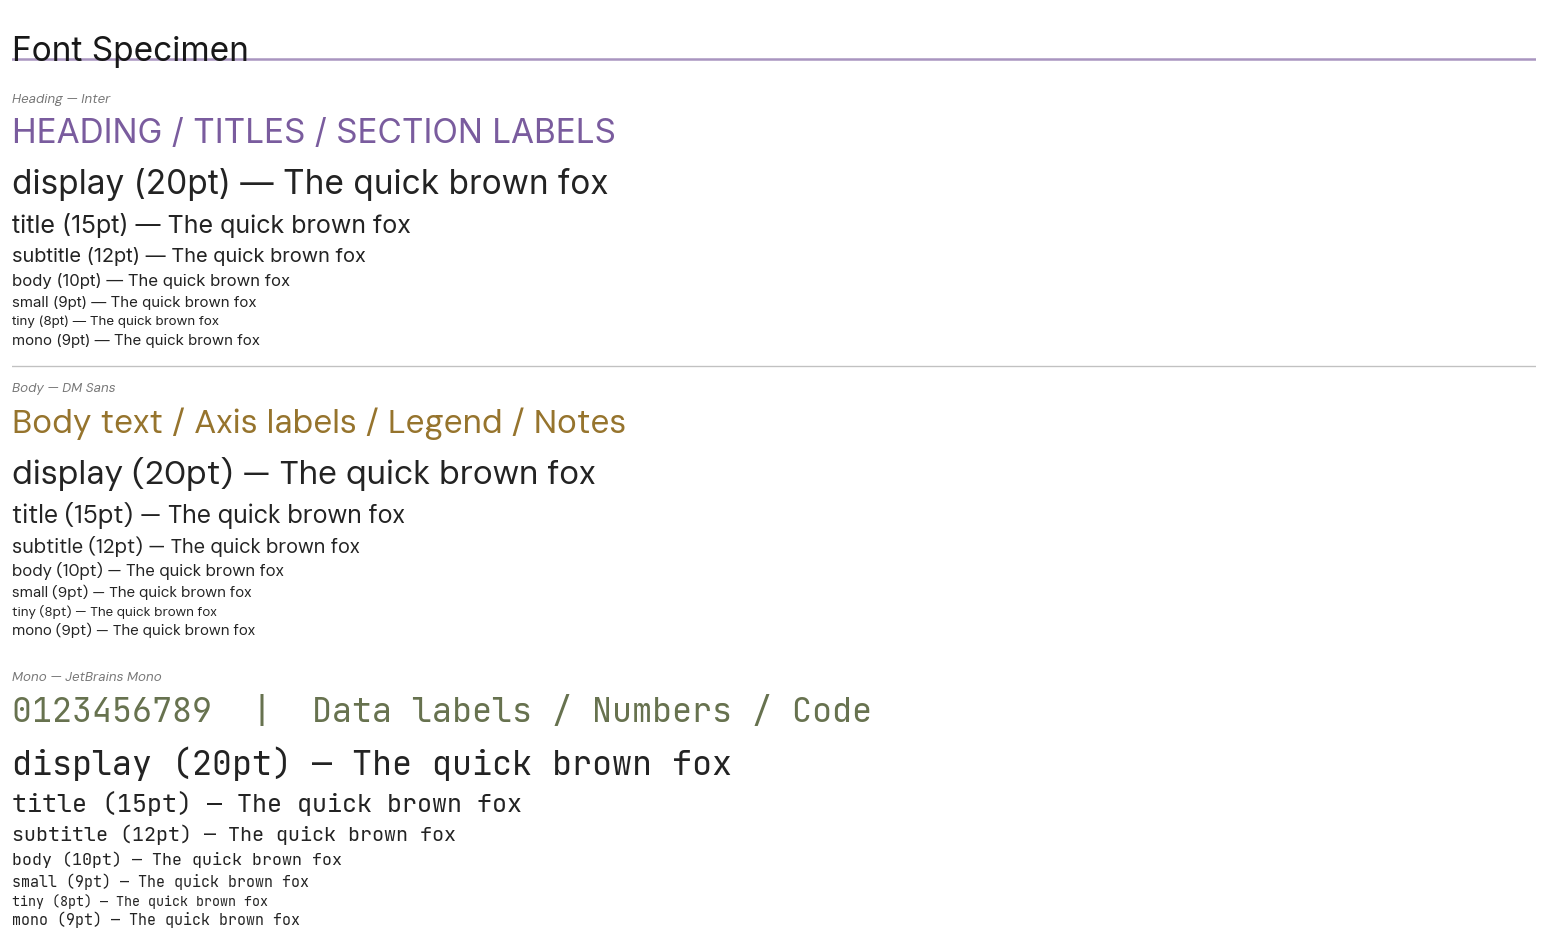

In [3]:
# Quick visual reference for the project's colour tokens and fonts
show_tokens()
show_fonts()

## Data Loading

In [4]:
# repo_root is defined in the Environment cell above.
# Point DATA_PATH at your dataset inside the Datasets folder.
DATA_PATH = os.path.join(repo_root, 'Datasets', 'Home Credit Default Risk', 'application_train.csv')

df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns from {DATA_PATH}")
df.head()

Loaded 307,511 rows × 122 columns from c:\Users\evanr\OneDrive\Desktop\CreditRiskLearning\Datasets\Home Credit Default Risk\application_train.csv


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,-3648.00,-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,-1186.00,-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,135000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,-4260.00,-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.0

# Project Body

## 1. First Look

### Data Shape

**Prediction:** Expecting large dataset with significant breadth and volume 

In [5]:
df.shape

(307511, 122)

**Obvervation:** 300k+ Rows and 122 Columns. 

**Decision:** Will need to split into statistical categories and potentially similar buckets (i.e. applicant data, security data, social data) for further assessment as attempting look at this number of columns as a whole group will make it difficult to draw tangible conslusions.

### Class Imbalance

**Prediction:** Typically defaulters are a very small percentage of a mortgage loan book as the financial health of bank is reliant on this percentage staying low given the huge losses taken upon mortgage default.

In [6]:
df["TARGET"].value_counts(normalize=True)

TARGET
0   0.92
1   0.08
Name: proportion, dtype: float64

**Observation:** 92% Non Defaulters vs 8% Defaulters

**Decision:** Non-Defualters make up a large portion of the loan book as expected, however 8% default rate is still extremely high given industry averages (insert industry average default rate). Indicates the lender has already priced in a riskier target market through rates/fees or is in a vulnerable financial position if the default is not addressed meaningfully through either policy changes or financial controls.

## 2. Data Quality and Missingess

**Prediction:** Expecting large portion of data to be missing for various reasons, such as length of employment missing due to an applicant potentially being unemployed (MNAR). These types of missingness relationship will be established across variables by looking at cross-validation.

### 2.1 Statisitcal Subsets

Splitting data up into continuous, discrete, nominal, ordinal and binary subsets.

In [ ]:
# Create a statistical column types dicionary

column_stat_types = {}


In [11]:
# Check Numerical Data Types

df.dtypes


SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE                str
CODE_GENDER                       str
FLAG_OWN_CAR                      str
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

In [14]:
# Filtering numerical type columns first

numerical_cols = df.select_dtypes(include='number').columns

print(numerical_cols)

# Filtering object type columns

object_cols = df.select_dtypes(include='object').columns

print(object_cols)

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=106)
Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='str')


C:\Users\evanr\AppData\Local\Temp\ipykernel_96860\3782641357.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include='object').columns


In [19]:
# Check numerical columns unique data types
df[numerical_cols].dtypes.value_counts()

# Assign all float types to continuous columns - will check back
continuous_cols = df[numerical_cols].select_dtypes(include='float64').columns

df[continuous_cols].sample(10)





float64    65
int64      41
Name: count, dtype: int64

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,OWN_CAR_AGE,CNT_FAM_MEMBERS,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
208162,135000.00,454810.50,54103.50,432000.00,0.01,-9355.00,NaN,1.00,NaN,0.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-436.00,NaN,NaN,NaN,NaN,NaN,NaN
120933,247500.00,592560.00,32274.00,450000.00,0.02,-5075.00,12.00,2.00,NaN,0.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,1.00,1.00,-234.00,NaN,NaN,NaN,NaN,NaN,NaN
67380,112500.00,607500.00,31149.00,607500.00,0.02,-7316.00,NaN,2.00,NaN,0.26,0.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00,0.00,5.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00
62284,72000.00,225000.00,14508.00,225000.00,0.01,-4183.00,16.00,3.00,NaN,0.26,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,0.00,2.00,0.00,-3194.00,0.00,0.00,0.00,0.00,0.00,2.00
103066,180000.00,1258650.00,51943.50,1125000.00,0.02,-6009.00,NaN,2.00,0.54,0.64,0.41,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,-1864.00,0.00,0.00,0.00,0.00,1.00,0.00
176843,315000.00,547339.50,29821.50,409500.00,0.07,-1903.00,NaN,2.00,NaN,0.74,0.15,0.24,0.12,1.00,0.95,0.15,0.37,0.16,0.53,0.42,0.03,0.15,0.14,0.00,0.07,0.19,0.11,1.00,0.95,0.15,0.40,0.17,0.38,0.42,0.02,0.17,0.10,0.00,0.06,0.22,0.12,1.00,0.95,0.15,0.40,0.17,0.54,0.42,0.03,0.15,0.12,0.00,0.07,0.17,4.00,2.00,4.00,2.00,-1040.00,0.00,0.00,0.00,0.00,0.00,1.00
176080,81000.00,376920.00,20574.00,270000.00,0.02,-4353.00,NaN,2.00,NaN,0.31,0.15,NaN,NaN,0.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01,NaN,NaN,NaN,NaN,0.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01,NaN,NaN,NaN,NaN,0.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01,NaN,NaN,0.01,0.00,0.00,0.00,0.00,-642.00,0.00,0.00,0.00,0.00,0.00,4.00
2460,202500.00,382500.00,36261.00,382500.00,0.03,-7665.00,4.00,2.00,0.28,0.29,0.67,0.08,NaN,0.98,NaN,NaN,0.00,0.14,0.17,NaN,NaN,NaN,NaN,NaN,NaN,0.08,NaN,0.98,NaN,NaN,0.00,0.14,0.17,NaN,NaN,NaN,NaN,NaN,NaN,0.08,NaN,0.98,NaN,NaN,0.00,0.14,0.17,NaN,NaN,NaN,NaN,NaN,NaN,0.06,0.00,0.00,0.00,0.00,-2864.00,0.00,0.00,0.00,0.00,0.00,0.00
112745,45000.00,225000.00,15219.00,225000.00,0.01,-6329.00,NaN,2.00,0.62,0.33,0.47,0.02,NaN,0.98,NaN,NaN,0.00,0.07,0.04,NaN,NaN,NaN,0.01,NaN,0.00,0.02,NaN,0.98,NaN,NaN,0.00,0.07,0.04,NaN,NaN,NaN,0.01,NaN,0.00,0.02,NaN,0.98

### 2.2 Thematic Subsets

### 2.3 Missingness Assessment

#### Bar Chart

Visualisation of Missingness for Columns with > 5% of data missing. Does not account for incorrect missing entries.

,index,0
0,SK_ID_CURR,0.00
1,TARGET,0.00
2,NAME_CONTRACT_TYPE,0.00
3,CODE_GENDER,0.00
4,FLAG_OWN_CAR,0.00


,column,pct
48,COMMONAREA_AVG,69.87
62,COMMONAREA_MODE,69.87
76,COMMONAREA_MEDI,69.87
84,NONLIVINGAPARTMENTS_MEDI,69.43
70,NONLIVINGAPARTMENTS_MODE,69.43


<Figure size 2052x2052 with 0 Axes>

Text(0.5, 1.0, 'Missingness Percentage for Columns With More than 5% of Data Missing')

Text(0.5, 0, 'Percentage Missing')

Text(0, 0.5, 'Column')

[Text(0, 0, '69.9%'),
 Text(0, 0, '69.9%'),
 Text(0, 0, '69.9%'),
 Text(0, 0, '69.4%'),
 Text(0, 0, '69.4%'),
 Text(0, 0, '69.4%'),
 Text(0, 0, '68.4%'),
 Text(0, 0, '68.4%'),
 Text(0, 0, '68.4%'),
 Text(0, 0, '68.4%'),
 Text(0, 0, '67.8%'),
 Text(0, 0, '67.8%'),
 Text(0, 0, '67.8%'),
 Text(0, 0, '66.5%'),
 Text(0, 0, '66.5%'),
 Text(0, 0, '66.5%'),
 Text(0, 0, '66.0%'),
 Text(0, 0, '59.4%'),
 Text(0, 0, '59.4%'),
 Text(0, 0, '59.4%'),
 Text(0, 0, '58.5%'),
 Text(0, 0, '58.5%'),
 Text(0, 0, '58.5%'),
 Text(0, 0, '56.4%'),
 Text(0, 0, '55.2%'),
 Text(0, 0, '55.2%'),
 Text(0, 0, '55.2%'),
 Text(0, 0, '53.3%'),
 Text(0, 0, '53.3%'),
 Text(0, 0, '53.3%'),
 Text(0, 0, '50.8%'),
 Text(0, 0, '50.7%'),
 Text(0, 0, '50.7%'),
 Text(0, 0, '50.7%'),
 Text(0, 0, '50.3%'),
 Text(0, 0, '50.3%'),
 Text(0, 0, '50.3%'),
 Text(0, 0, '50.2%'),
 Text(0, 0, '50.2%'),
 Text(0, 0, '50.2%'),
 Text(0, 0, '50.2%'),
 Text(0, 0, '49.8%'),
 Text(0, 0, '49.8%'),
 Text(0, 0, '49.8%'),
 Text(0, 0, '48.8%'),
 Text(0, 0

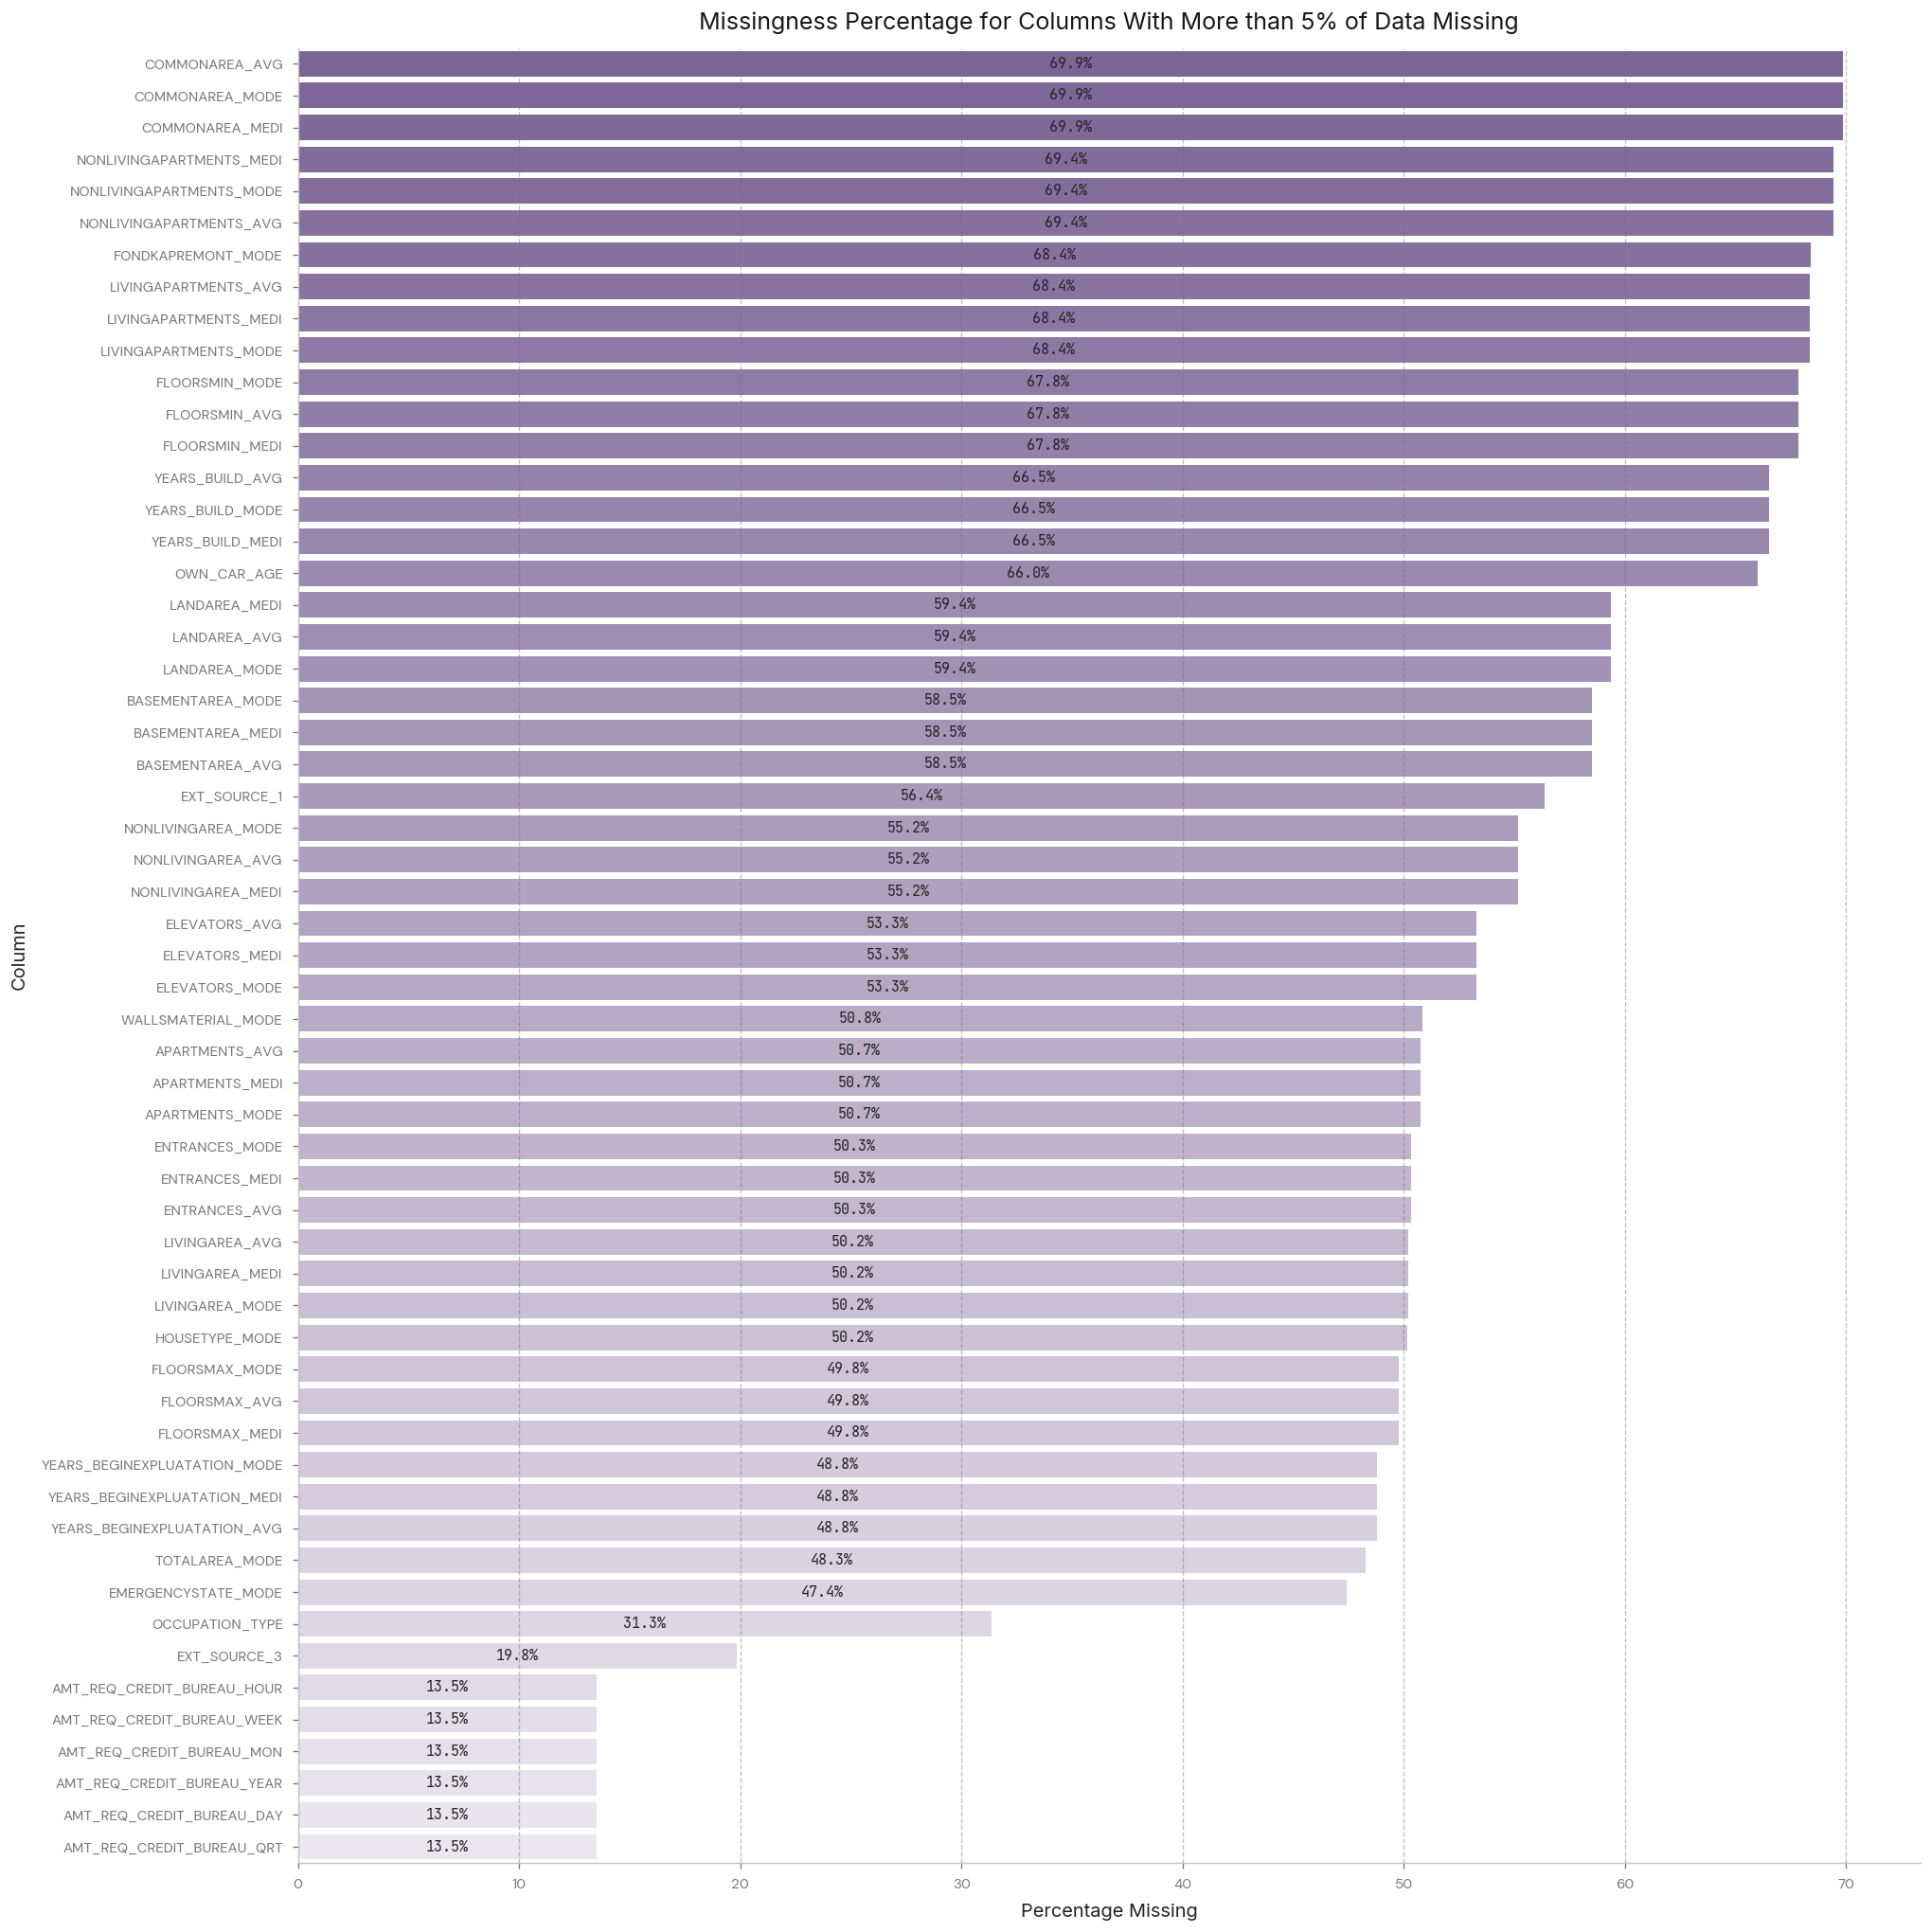

In [8]:
missingness_pct = (df.isnull().sum()/len(df) * 100).reset_index()

missingness_pct.head(5)

missingness_pct = missingness_pct.rename(columns={'index': 'column', 0 : 'pct'})

missingness_pct = missingness_pct.sort_values('pct', ascending=False)

missingness_pct.head(5)

missingness_pct = missingness_pct[missingness_pct['pct'] >= 5]

# Setting up gradient across bars
n_bars = len(missingness_pct)
alphas = np.linspace(1.0, 0.15, n_bars)

# Set Figure size with y
plt.figure(figsize=(len(missingness_pct)*0.3,len(missingness_pct)*0.3 ))

# Assigning Columns to axes and call SNS
ax = sns.barplot(missingness_pct, x='pct', y='column')

# Assigning gradient to bar chart
for bar, alpha in zip(ax.patches, alphas):
    bar.set_alpha(alpha)

# Setting chart labels and titles
ax.set_title('Missingness Percentage for Columns With More than 5% of Data Missing', fontfamily=f('heading'), fontsize= s('title'))
ax.set_xlabel("Percentage Missing", fontfamily=f('heading'), fontsize=s('subtitle'))
ax.set_ylabel("Column", fontfamily=f('heading'), fontsize=s('subtitle'))

# Setting bar labels
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontsize=s('small'), fontfamily=f('mono'), label_type='center')

# Rendering chart
plt.tight_layout()
plt.show()


#### Missingness Heatmap

<Axes: >

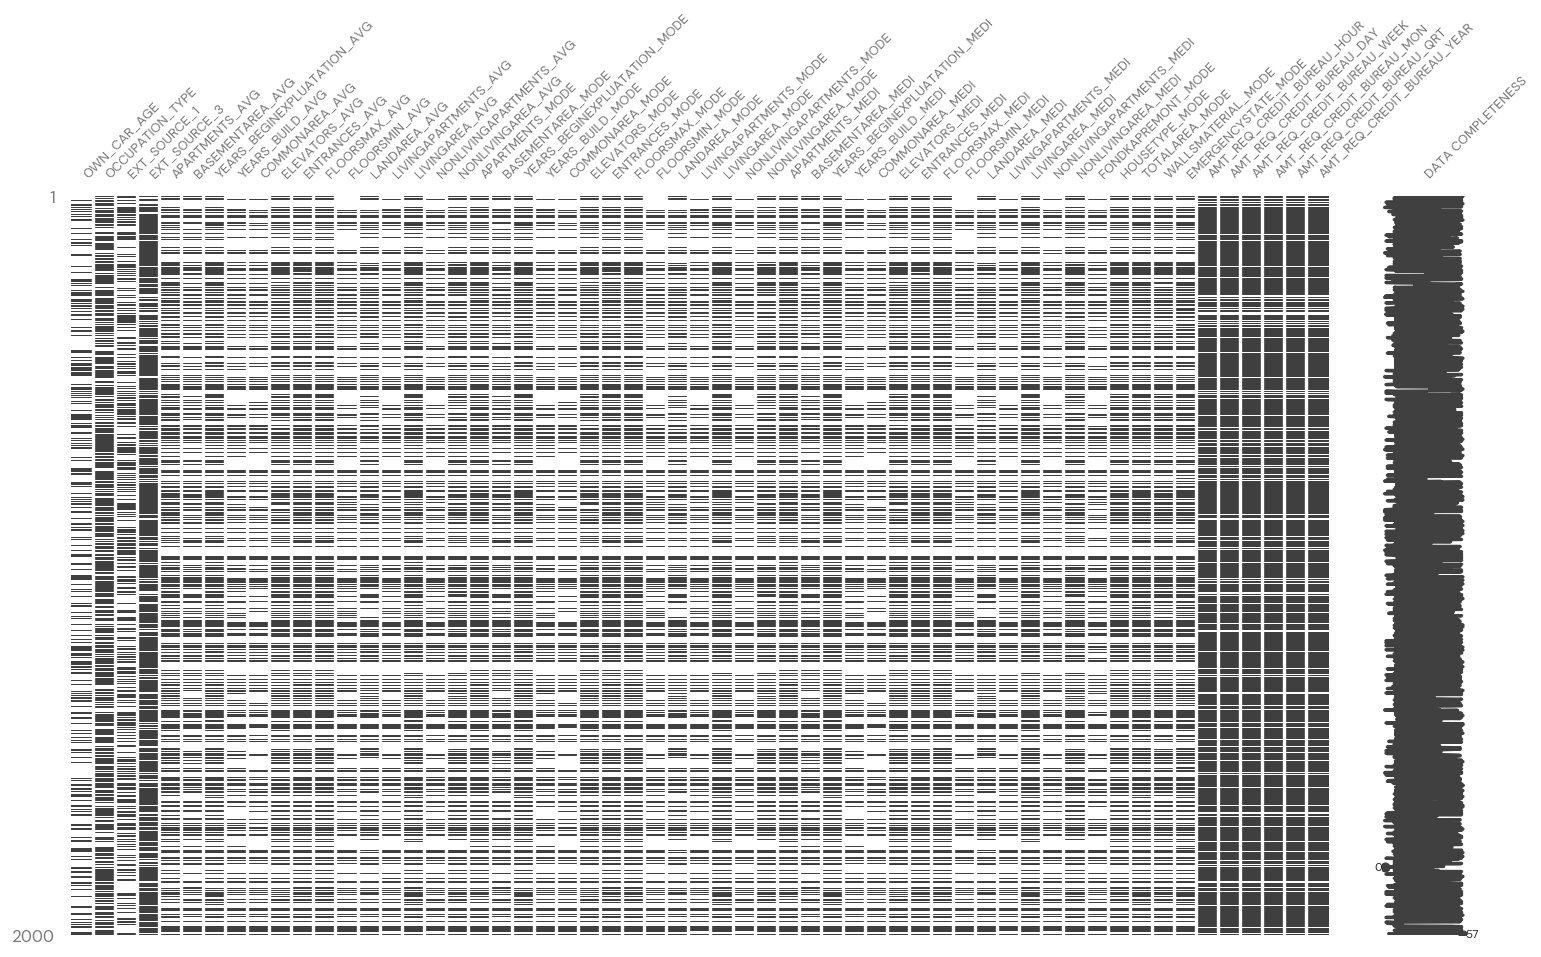

In [9]:
missingness_pct_2 = df.isnull().sum() / len(df)

missing_subset_cols = missingness_pct_2[missingness_pct_2 >= 0.05].index

msno.matrix(df[missing_subset_cols].sample(2000), labels=True, fontsize=8,
            figsize=(15, 8))

## 3. Univariate EDA

## 4. Target Relationship Scan

## 5. WOE/IV Computation

## 6. Findings Summary

## 7. Next Steps